# ML-03 — Frame Your Lane as an ML Task

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Maryam-Shile/flyrank_ml_internship/blob/main/work/notebooks/w02_ml_task_framing.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. My lane as an ML task (type)

*Classification, clustering, ranking, or scoring — which one, and why?*

The task is ultimately a clustering task. Fot the diagnostic tool, it uses unsupervised machine learning in grouping low performance pages based on similar features which can be easily used in examining the possible cause of failure.

## 2. Target or proxy

*What would you predict? Where does that label come from — observed outcome or a defined rule?*

There is no real target here. An engineered feature called perfomance score is used to select low performing contents which will be further clustered to investigate failure mode, based on the data the team can access.
All performance metrics are eliminated from this final layer to prevent leakage because the performance score is like an aggregate of the these scores.

Why cant we have a target?
perfomance score is an aggregate of all perfomance metrics in this dataset. Is it possible to that content-specific data explains why the pages are not perfoming well?

First we will try to find out using a logistic regression.

In [82]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GroupShuffleSplit, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, mean_absolute_error, root_mean_squared_error, mean_absolute_percentage_error, r2_score


In [41]:
df = pd.read_csv('/content/info_data.csv')
df.head()

,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,scroll_events_90d_rank,days_with_impressions_rank,days_with_sessions_rank,ctr_rank,engagement_rate_rank,scroll_rate_rank,ai_traffic_pct_rank,avg_position_rank,performance_score,perfomance_label
0,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,0.498458,0.801941,0.586588,0.453561,0.35110,0.634831,0.466894,0.316436,54.491081,good
1,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,0.790210,0.801941,0.635627,0.514391,0.35110,0.804298,0.466894,0.112320,58.007439,good
2,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,0.985428,0.801941,0.870329,0.576793,0.35110,0.771244,0.466894,0.071551,64.889325,good
3,content_9a34b442b552,client_8722616204,0.0,0.00,LOW,0.00,keyword article,informational,3059.0,20810.0,...,0.189503,0.130427,0.078667,0.205738,0.35110,0.190772,0.466894,0.754071,27.663007,not good
4,content_5e6c160719bc,client_6208ef0f77,0.0,0.00,LOW,0.00,keyword article,informational,3807.0,24228.0,...,0.877857,0.484460,0.916919,0.514391,0.88079,0.556063,0.466894,0.063441,68.517192,good


In [42]:
df.iloc[0]

,0
content_id,content_a1fb4e703a9e
client_id,client_4e07408562
search_volume,90.0
competition,0.01
competition_level,LOW
cpc,0.05
content_type,keyword article
main_intent,informational
word_count,2481.0
char_count,15562.0


Data Cleaning
remove all performance metrics except the agregated scores to prevent leakage



In [43]:
performance_cols = ['impressions_90d', 'clicks_90d', 'pageviews_90d',
       'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d',
       'days_with_impressions', 'days_with_sessions', 'ctr', 'engagement_rate', 'scroll_rate', 'ai_traffic_pct', 'trend_pct', 'avg_position', 'trend_direction']

for col in df.columns:
  if '_rank' in col:
    performance_cols.append(col)

df = df.drop(columns = performance_cols)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16538 entries, 0 to 16537
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   content_id              16538 non-null  object 
 1   client_id               16538 non-null  object 
 2   search_volume           16395 non-null  float64
 3   competition             16395 non-null  float64
 4   competition_level       16395 non-null  object 
 5   cpc                     16395 non-null  float64
 6   content_type            16538 non-null  object 
 7   main_intent             16538 non-null  object 
 8   word_count              12472 non-null  float64
 9   char_count              12472 non-null  float64
 10  provider_used           5283 non-null   object 
 11  model_used              13746 non-null  object 
 12  content_age_days        16538 non-null  int64  
 13  days_since_last_update  16538 non-null  int64  
 14  performance_score       16538 non-null

Dropping main_intent because this data is only for informational content, so no variations here

In [44]:
df = df.drop(columns = ['main_intent', 'content_type'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16538 entries, 0 to 16537
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   content_id              16538 non-null  object 
 1   client_id               16538 non-null  object 
 2   search_volume           16395 non-null  float64
 3   competition             16395 non-null  float64
 4   competition_level       16395 non-null  object 
 5   cpc                     16395 non-null  float64
 6   word_count              12472 non-null  float64
 7   char_count              12472 non-null  float64
 8   provider_used           5283 non-null   object 
 9   model_used              13746 non-null  object 
 10  content_age_days        16538 non-null  int64  
 11  days_since_last_update  16538 non-null  int64  
 12  performance_score       16538 non-null  float64
 13  perfomance_label        16538 non-null  object 
dtypes: float64(6), int64(2), object(6)
mem

Correct the typo

In [45]:
df.rename(columns = {'perfomance_label':'performance_label'}, inplace = True)
df

,content_id,client_id,search_volume,competition,competition_level,cpc,word_count,char_count,provider_used,model_used,content_age_days,days_since_last_update,performance_score,performance_label
0,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,2481.0,15562.0,NaN,gemini-3-flash-preview,445,25,54.491081,good
1,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,3515.0,23643.0,NaN,gemini-2.5-flash,141,20,58.007439,good
2,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,2803.0,17469.0,NaN,gemini-3-flash-preview,263,14,64.889325,good
3,content_9a34b442b552,client_8722616204,0.0,0.00,LOW,0.00,3059.0,20810.0,google,gemini-3-flash-preview,90,20,27.663007,not good
4,content_5e6c160719bc,client_6208ef0f77,0.0,0.00,LOW,0.00,3807.0,24228.0,google,gemini-3-flash-preview,90,20,68.517192,good
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16533,content_9bb9a0584cae,client_8527a891e2,210.0,0.00,LOW,0.00,1446.0,9001.0,NaN,gpt-4o-mini,146,8,24.069443,not good
16534,content_e859812ce999,client_19581e27de,10.0,0.20,LOW,0.00,NaN,NaN,NaN,NaN,148,104,71.416645,good
16535,content_b7fa2d76e5ae,client_4e07408562,70.0,0.00,LOW,0.00,2501.0,15617.0,NaN,gemini-3-flash-preview,280,14,45.736019,good
16536,content_23dce6a656e6,client_e29c9c180c,140.0,0.99,HIGH,0.22,1508.0,9735.0,NaN,gemini-2.5-flash,348,20,20.121252,not good


In [46]:
df.shape

(16538, 14)

In [47]:
df.columns

Index(['content_id', 'client_id', 'search_volume', 'competition',
       'competition_level', 'cpc', 'word_count', 'char_count', 'provider_used',
       'model_used', 'content_age_days', 'days_since_last_update',
       'performance_score', 'performance_label'],
      dtype='object')

Select feature and target variables

In [48]:
X = df.drop(columns = ['performance_label', 'performance_score']).copy()
y = df['performance_label'].copy()

In [49]:
cat_cols = ['content_id', 'client_id', 'competition_level', 'provider_used', 'model_used']
num_cols = ['search_volume', 'competition', 'cpc', 'word_count', 'char_count', 'content_age_days', 'days_since_last_update']

len(cat_cols) + len(num_cols)


12

Inspect to understand structure, distribution and find missing values

In [50]:
for i in cat_cols:
  print(f'{i}: {X[i].nunique()}')
  print()

content_id: 16538

client_id: 31

competition_level: 3

provider_used: 2

model_used: 5



In [51]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16538 entries, 0 to 16537
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   content_id              16538 non-null  object 
 1   client_id               16538 non-null  object 
 2   search_volume           16395 non-null  float64
 3   competition             16395 non-null  float64
 4   competition_level       16395 non-null  object 
 5   cpc                     16395 non-null  float64
 6   word_count              12472 non-null  float64
 7   char_count              12472 non-null  float64
 8   provider_used           5283 non-null   object 
 9   model_used              13746 non-null  object 
 10  content_age_days        16538 non-null  int64  
 11  days_since_last_update  16538 non-null  int64  
dtypes: float64(5), int64(2), object(5)
memory usage: 1.5+ MB


In [52]:
for j in num_cols:
  print(f'{j}: {X[j].describe()}')
  print()

search_volume: count    16395.000000
mean       188.713632
std       1832.005596
min          0.000000
25%          0.000000
50%          0.000000
75%         20.000000
max      74000.000000
Name: search_volume, dtype: float64

competition: count    16395.000000
mean         0.067029
std          0.179170
min          0.000000
25%          0.000000
50%          0.000000
75%          0.020000
max          1.000000
Name: competition, dtype: float64

cpc: count    16395.000000
mean         0.320859
std          1.916328
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        100.360000
Name: cpc, dtype: float64

word_count: count    12472.000000
mean      3285.057649
std       1413.687294
min        424.000000
25%       2571.000000
50%       2941.000000
75%       3696.250000
max       9179.000000
Name: word_count, dtype: float64

char_count: count     12472.000000
mean      21639.514513
std        9517.585021
min        3143.000000
25%       1683

Majority of search volume, competition and cpc, majority of which are understood to be placeholders for unavailable data. These will be changed to nan.

In [53]:
search_volume = X[X['search_volume'] == 0.0]
search_volume.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9060 entries, 1 to 16537
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   content_id              9060 non-null   object 
 1   client_id               9060 non-null   object 
 2   search_volume           9060 non-null   float64
 3   competition             9060 non-null   float64
 4   competition_level       9060 non-null   object 
 5   cpc                     9060 non-null   float64
 6   word_count              7924 non-null   float64
 7   char_count              7924 non-null   float64
 8   provider_used           3828 non-null   object 
 9   model_used              8448 non-null   object 
 10  content_age_days        9060 non-null   int64  
 11  days_since_last_update  9060 non-null   int64  
dtypes: float64(5), int64(2), object(5)
memory usage: 920.2+ KB


In [54]:
X['search_volume'] = X['search_volume'].replace(0, np.nan)
X['competition'] = X['competition'].replace(0, np.nan)
X['cpc'] = X['cpc'].replace(0, np.nan)




Both Search_volume and cpc are skewed and need to normalized. log1p is used due to extreme long tails and the presence of zeros which returns an a -inf when logged.

In [55]:
X['search_volume'] = np.log1p(X['search_volume'])
X['cpc'] = np.log1p(X['cpc'])

Ensure that there are no multicollinearity among the feature variables.

In [56]:
X[num_cols].corr()

,search_volume,competition,cpc,word_count,char_count,content_age_days,days_since_last_update
search_volume,1.000000,-0.080635,-0.032930,0.047852,0.026663,0.212147,-0.016007
competition,-0.080635,1.000000,0.239879,-0.138619,-0.126384,-0.123987,0.032149
cpc,-0.032930,0.239879,1.000000,-0.066685,-0.041568,0.013431,-0.017487
word_count,0.047852,-0.138619,-0.066685,1.000000,0.961054,0.000257,0.411143
char_count,0.026663,-0.126384,-0.041568,0.961054,1.000000,-0.035103,0.380572
content_age_days,0.212147,-0.123987,0.013431,0.000257,-0.035103,1.000000,-0.000782
days_since_last_update,-0.016007,0.032149,-0.017487,0.411143,0.380572,-0.000782,1.000000


In [57]:
X_features = X.drop(columns = ['word_count'], axis = 1).copy()

content and client id are simply identifiers and are not particularly relevant to this model. However, client id has the potential of causing leakage because there are only about 30 unique clients. If the model trains on a client data and still finds the same client under test, it could lead to data leakage. More on this subsequently

In [58]:
client_group = X['client_id']
content_group = X['content_id']

In [59]:
X_features = X_features.drop(columns = ['client_id', 'content_id'], axis = 1)

In [60]:
X_features

,search_volume,competition,competition_level,cpc,char_count,provider_used,model_used,content_age_days,days_since_last_update
0,4.510860,0.01,LOW,0.048790,15562.0,NaN,gemini-3-flash-preview,445,25
1,NaN,NaN,LOW,NaN,23643.0,NaN,gemini-2.5-flash,141,20
2,NaN,NaN,LOW,NaN,17469.0,NaN,gemini-3-flash-preview,263,14
3,NaN,NaN,LOW,NaN,20810.0,google,gemini-3-flash-preview,90,20
4,NaN,NaN,LOW,NaN,24228.0,google,gemini-3-flash-preview,90,20
...,...,...,...,...,...,...,...,...,...
16533,5.351858,NaN,LOW,NaN,9001.0,NaN,gpt-4o-mini,146,8
16534,2.397895,0.20,LOW,NaN,NaN,NaN,NaN,148,104
16535,4.262680,NaN,LOW,NaN,15617.0,NaN,gemini-3-flash-preview,280,14
16536,4.948760,0.99,HIGH,0.198851,9735.0,NaN,gemini-2.5-flash,348,20


In [61]:
cat_cols = ['competition_level', 'provider_used', 'model_used']
num_cols = ['search_volume', 'competition', 'cpc', 'char_count', 'content_age_days', 'days_since_last_update']

len(cat_cols) + len(num_cols)


9

Set up the pipeline for preprocessing and modelling

In [62]:
num_pipeline = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
cat_pipeline = Pipeline(
    steps = [
        ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num_pipeline', num_pipeline, num_cols),
        ('cat_pipeline', cat_pipeline, cat_cols)
    ])

pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', LogisticRegression())
    ]
)

Instead of train_test_spit, we need to split our data using a shuffle technique in  way that one client does not show in the training and testing data at the same time


In [63]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X_features, y, groups = client_group))

X_train, X_test = X_features.iloc[train_idx].copy(), X_features.iloc[test_idx].copy()
y_train, y_test = y.iloc[train_idx].copy(), y.iloc[test_idx].copy()

In [64]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 12845 entries, 1 to 16537
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   search_volume           5469 non-null   float64
 1   competition             3579 non-null   float64
 2   competition_level       12796 non-null  object 
 3   cpc                     2168 non-null   float64
 4   char_count              9399 non-null   float64
 5   provider_used           4145 non-null   object 
 6   model_used              10053 non-null  object 
 7   content_age_days        12845 non-null  int64  
 8   days_since_last_update  12845 non-null  int64  
dtypes: float64(4), int64(2), object(3)
memory usage: 1003.5+ KB


In [65]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3693 entries, 0 to 16536
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   search_volume           1866 non-null   float64
 1   competition             1001 non-null   float64
 2   competition_level       3599 non-null   object 
 3   cpc                     583 non-null    float64
 4   char_count              3073 non-null   float64
 5   provider_used           1138 non-null   object 
 6   model_used              3693 non-null   object 
 7   content_age_days        3693 non-null   int64  
 8   days_since_last_update  3693 non-null   int64  
dtypes: float64(4), int64(2), object(3)
memory usage: 288.5+ KB


train and evaluate the classification model

In [66]:
pipeline.fit(X_train, y_train)
predictions = pipeline.predict(X_test)
prediction_probabilities = pipeline.predict_proba(X_test)
print()
print(classification_report(y_test, predictions))


              precision    recall  f1-score   support

        good       0.50      0.91      0.64      1791
    not good       0.61      0.13      0.22      1902

    accuracy                           0.51      3693
   macro avg       0.55      0.52      0.43      3693
weighted avg       0.56      0.51      0.43      3693



In [67]:
pipeline.predict_proba(X_test)

array([[0.85088571, 0.14911429],
       [0.66961739, 0.33038261],
       [0.66844576, 0.33155424],
       ...,
       [0.67081356, 0.32918644],
       [0.78096927, 0.21903073],
       [0.55483126, 0.44516874]])

This shows that the model is not behaving better than a random guess, showing little relationship. We may guess that performance label lacks gradient because of its binning logic-every performance score at and below 40 were labelled 'not good' while everything above that threshold is labelled 'good' It follows the intuition of the trend direction, where performance score of 50 is assummed to be stable, performing averagely across all performance metrics.

Next we will try to use the raw performance score in a regression task. Would we be able to detect the nuances then?

In [68]:
y = df['performance_score'].copy()

In [69]:
cat_cols = ['competition_level', 'provider_used', 'model_used']
num_cols = ['search_volume', 'competition', 'cpc', 'char_count', 'content_age_days', 'days_since_last_update']

len(cat_cols) + len(num_cols)

9

In [70]:
num_pipeline = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
cat_pipeline = Pipeline(
    steps = [
        ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num_pipeline', num_pipeline, num_cols),
        ('cat_pipeline', cat_pipeline, cat_cols)
    ])

param_dist = {
    'rf__n_estimators': [100, 200, 300],
    'rf__max_depth': [10, 16, 20, None],
    'rf__min_samples_split': [2, 5, 10],
    'rf__min_samples_leaf': [1, 2, 4],
    'rf__max_features': ['sqrt', 'log2', None]
}

pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('rf', RandomForestRegressor(random_state=42))
    ])

search = RandomizedSearchCV(
    pipeline,
    param_dist,
    n_iter=25,          # sample 25 combos instead of all 243
    cv=3,               # 3 folds instead of 5
    scoring='neg_mean_absolute_error',
    verbose=2,
    n_jobs=-1,
    random_state=42)

In [71]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X_features, y, groups = client_group))

X_train, X_test = X_features.iloc[train_idx].copy(), X_features.iloc[test_idx].copy()
y_train, y_test = y.iloc[train_idx].copy(), y.iloc[test_idx].copy()

In [72]:
search.fit(X_train, y_train)
print("Best Parameters found:", search.best_params_)
print("Best Negative MSE Score:", search.best_score_)

Fitting 3 folds for each of 25 candidates, totalling 75 fits
Best Parameters found: {'rf__n_estimators': 200, 'rf__min_samples_split': 10, 'rf__min_samples_leaf': 1, 'rf__max_features': 'log2', 'rf__max_depth': 20}
Best Negative MSE Score: -11.170071730137176


In [73]:
prediction = search.predict(X_test)
print(f'mae: {mean_absolute_error(y_test, prediction)}')
print(f'r_squared: {r2_score(y_test, prediction)}')

mae: 13.582378353422076
r_squared: 0.05040516188685018


In [74]:
y.describe()

,performance_score
count,16538.000000
mean,49.916277
std,17.148341
min,20.121252
25%,35.720974
50%,47.882905
75%,63.523520
max,93.650709


The mean absolute error is close to the standard deviation and the r_squared score shows that this model is explaining avout 10% of the variation in the detaset. Combining the insights from the regression and classification tasks, it is safe to say that the features that drive the performance metrics are beyond the content-related features in this dataset and it may be impossible to use these features to predict how well the content will perform.

## 3. Success metric

*One metric you can defend. What number means 'good'?*

The analysis above clearly shows that content performance is somewhat independent of the content characteristics provided within the dataset. However, the performance scores can be used to separate low performing contents and analyse them further for better insights.

In [75]:
df.columns

Index(['content_id', 'client_id', 'search_volume', 'competition',
       'competition_level', 'cpc', 'word_count', 'char_count', 'provider_used',
       'model_used', 'content_age_days', 'days_since_last_update',
       'performance_score', 'performance_label'],
      dtype='object')

Select low performers using quartile logic previously explained.

In [93]:
low_cut_off = df['performance_score'].quantile(0.4)
new_data = df[df['performance_score'] <= low_cut_off]

client_group = new_data['client_id']
content_group = new_data['content_id']

new_data = new_data.drop(columns = ['content_id', 'client_id', 'word_count'])

Clean up data as done before

In [94]:
new_data['search_volume'] = new_data['search_volume'].replace(0, np.nan)
new_data['competition'] = new_data['competition'].replace(0, np.nan)
new_data['cpc'] = new_data['cpc'].replace(0, np.nan)


new_data['search_volume'] = np.log1p(new_data['search_volume'])
new_data['cpc'] = np.log1p(X['cpc'])

In [95]:
num_pipeline = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
cat_pipeline = Pipeline(
    steps = [
        ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num_pipeline', num_pipeline, num_cols),
        ('cat_pipeline', cat_pipeline, cat_cols)
    ])
processed_data = preprocessor.fit_transform(new_data)

Use KMeans model to detect similar patterns among low performing pages

First we need to find out how many clusters are good enough

In [96]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

def calculate_elbow_inertia(data, max_k =10):
  inertia = []
  k_range = range(1, max_k + 1)

  for i in k_range:
    kmeans = KMeans(n_clusters = i, random_state = 42)
    kmeans.fit_predict(data)
    inertia.append(kmeans.inertia_)
  return list(k_range), inertia



In [97]:
k_range, inertia = calculate_elbow_inertia(processed_data, 10)


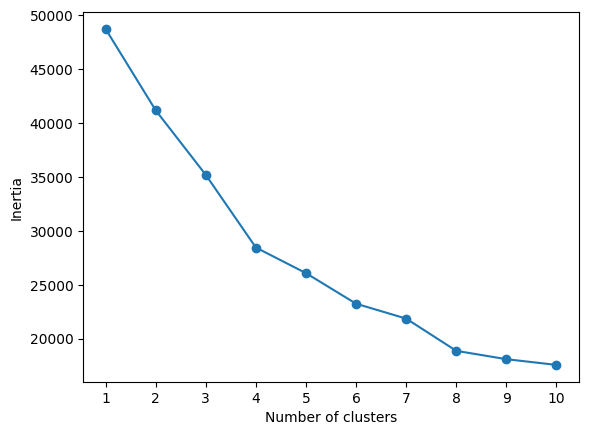

In [98]:
plt.plot(k_range, inertia, '-o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.xticks(k_range)
plt.show()

Technically, the elbow began around 4-5. 5 is selected for number of clusters.

In [99]:
model = KMeans(n_clusters = 6, random_state = 42)
model.fit(processed_data)
labels = model.predict(processed_data)

new_data['labels'] = labels

new_data

,search_volume,competition,competition_level,cpc,char_count,provider_used,model_used,content_age_days,days_since_last_update,performance_score,performance_label,labels
3,NaN,NaN,LOW,NaN,20810.0,google,gemini-3-flash-preview,90,20,27.663007,not good,3
7,2.397895,NaN,LOW,NaN,8469.0,NaN,gpt-4o-mini,238,103,36.525913,not good,2
8,NaN,NaN,LOW,NaN,18013.0,google,gemini-3-flash-preview,124,104,38.985065,not good,1
12,NaN,NaN,LOW,NaN,21571.0,google,gemini-3-flash-preview,118,20,34.962828,not good,3
18,6.175867,0.58,MEDIUM,0.736476,9052.0,openai,gpt-4o-mini,96,20,40.772572,not good,0
...,...,...,...,...,...,...,...,...,...,...,...,...
16518,NaN,NaN,LOW,NaN,43022.0,NaN,gemini-3-flash-preview,229,104,38.831255,not good,1
16521,NaN,NaN,LOW,NaN,35141.0,NaN,gemini-2.5-flash,225,20,32.925699,not good,3
16522,5.141664,0.16,LOW,0.842324,NaN,NaN,NaN,482,22,27.376235,not good,5
16533,5.351858,NaN,LOW,NaN,9001.0,NaN,gpt-4o-mini,146,8,24.069443,not good,2


## 4. The unit of analysis, as a real dataframe

*Load your lane's slice and show it: one row = one what?*

In [100]:
for i in range(0, 6, 1):
  print(f'cluster {i}')
  print(new_data[new_data['labels'] == i].describe())
  print()

cluster 0
       search_volume  competition         cpc    char_count  content_age_days  \
count     394.000000   394.000000  337.000000    230.000000        394.000000   
mean        3.885892     0.736091    0.776875  14198.143478        313.375635   
std         1.602277     0.220164    0.330192   5896.294734        143.841785   
min         2.397895     0.060000    0.019609   6597.000000         90.000000   
25%         2.397895     0.570000    0.565772   9078.500000        165.000000   
50%         3.433987     0.750000    0.791168  11376.500000        333.000000   
75%         4.888952     0.947500    0.989577  19321.750000        445.000000   
max         9.602450     1.000000    1.726097  37568.000000        557.000000   

       days_since_last_update  performance_score  labels  
count              394.000000         394.000000   394.0  
mean                38.819797          32.233585     0.0  
std                 38.574148           5.861433     0.0  
min                  1.0

In [101]:
numerical_summary = new_data.groupby('labels')[num_cols].mean()
numerical_summary

,search_volume,competition,cpc,char_count,content_age_days,days_since_last_update
labels,,,,,,
0,3.885892,0.736091,0.776875,14198.143478,313.375635,38.819797
1,3.400922,0.153836,0.194663,29849.479532,272.584767,109.297297
2,3.226206,0.151987,0.257711,9732.627649,251.779011,57.751766
3,3.004166,0.174045,0.363279,20919.948405,129.630854,17.857930
4,3.154908,0.120143,0.265627,19122.635821,441.856425,19.862886
5,6.814378,0.141362,0.514067,18005.989011,391.719917,36.840249


One row means one cluster. One cluster means one archtype possibly explaining its own unique failure mode.

In [102]:
for i in numerical_summary.columns:
  numerical_summary[i] = numerical_summary[i].rank(pct = True)

<Axes: ylabel='labels'>

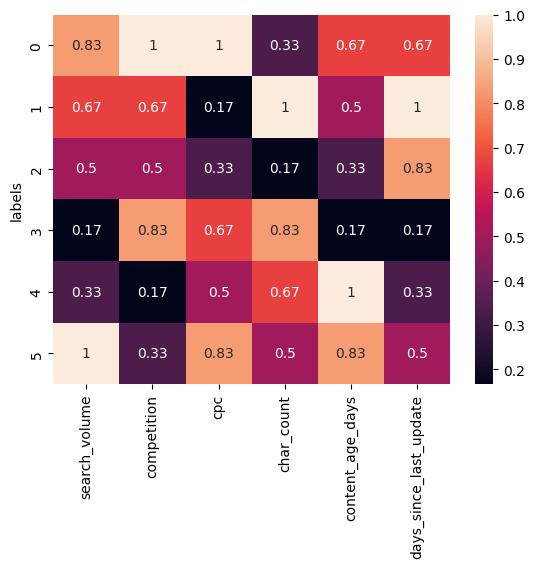

In [103]:
import seaborn as sns
sns.heatmap(numerical_summary, annot = True)

Result and discussion

archtype 0: These contents are not being searched frequently, possibly because the topic is unpopular as the competition and cpc are low as well.

archtype 1: Slightly higher search volume than the first archtype but competition is low and what is most striking is the length of the content and last time the content was updated.

archtype 2: High search volume in a competitive niche and that is evident with the cpc. This is worthy of review because of the risk of spending on a content noone is actually interacting with. It should be compared with competitor's content to see how it may be improved.

archtype 3: Moderate search volume in a low competition niche. This represents the group of contents that are old but are still valuable. It is hinting that the content itself needs to be refreshed for value.

archtype 4: These are the youngest in the group. And their low performance may be due to lack of data on their activity. They may be given some time to gather data for better insights.

## 5. Why ML beats a fixed rule here

*What makes the pattern too messy for an if-statement?*
One performance metric cannot tell the full story of the content. By first aggregating perfomance metrics and extracting the low performance contents, Using an unsupervised learning model has made it possible to properly group into possible archtypes. These archtypes offers a plausible explanation into various failure modes which could be a useful decision support for SEO teams.

This tool does not tell the exact reason for failure, but it can detect patterns within failing contents, giving the team a broad idea on what may be wrong before a proper human-led diagnosis.

In [104]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.